# Trader Performance vs Market Sentiment

Primetrade.ai Round-0 assignment notebook. This analysis joins Hyperliquid trader activity to Bitcoin Fear/Greed sentiment at the daily level and then compares performance, behavior, and trader segments across sentiment regimes.

## 1. Load Libraries and Configure Notebook

The notebook uses the reusable pipeline in `src/analyze_sentiment.py`, which keeps the analysis reproducible while avoiding duplicated logic.

In [11]:
from pathlib import Path
import sys
import importlib

import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.analyze_sentiment as analyze_sentiment
importlib.reload(analyze_sentiment)
from src.analyze_sentiment import load_data, prepare_data, build_tables

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

raw_trades, raw_sentiment = load_data()
trades, sentiment, merged = prepare_data(raw_trades, raw_sentiment)
tables = build_tables(raw_trades, raw_sentiment, trades, sentiment, merged)

print('Notebook environment ready.')

Notebook environment ready.


## 2. Load Both Datasets

The raw files are stored in `data/raw`. The tables below show the first rows and the key columns used in the analysis.

In [3]:
display(raw_sentiment.head())
display(raw_trades.head())

print('Sentiment shape:', raw_sentiment.shape)
print('Trader shape:', raw_trades.shape)
print('\nSentiment columns:', raw_sentiment.columns.tolist())
print('Trader columns:', raw_trades.columns.tolist())

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Sentiment shape: (2644, 4)
Trader shape: (211224, 16)

Sentiment columns: ['timestamp', 'value', 'classification', 'date']
Trader columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


## 3. Inspect Data Quality and Structure

The raw datasets are clean: no duplicate rows and no missing values in either source file. The only merge gap comes from a handful of trader rows outside the sentiment date range.

In [4]:
display(tables['raw_quality'])
display(tables['merge_coverage'])
display(tables['sentiment_counts'])

,dataset,rows,columns,missing_values,duplicate_rows
0,fear_greed_index,2644,4,0,0
1,hyperliquid_trader_data,211224,16,0,0


,metric,value
0,trade_rows,211224.000000
1,matched_rows,211218.000000
2,unmatched_rows,6.000000
3,match_rate,0.999972


,classification,trade_rows
0,Fear,61837
1,Greed,50303
2,Extreme Greed,39992
3,Neutral,37686
4,Extreme Fear,21400


## 4. Clean Timestamps and Align by Date

The trader timestamps are converted to daily dates and aligned to the sentiment index on the same calendar day. The merge coverage is effectively complete for the overlapping period.

In [5]:
display(trades[['date', 'Account', 'Direction', 'Closed PnL', 'Size USD']].head())
print('Aligned trader dates:', trades['date'].nunique())
print('Sentiment dates:', sentiment['date'].nunique())
print('Merged rows:', len(merged))
print('Matched rows:', int(merged['classification'].notna().sum()))

,date,Account,Direction,Closed PnL,Size USD
0,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Buy,0.0,7872.16
1,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Buy,0.0,127.68
2,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Buy,0.0,1150.63
3,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Buy,0.0,1142.04
4,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Buy,0.0,69.75


Aligned trader dates: 480
Sentiment dates: 2644
Merged rows: 211224
Matched rows: 211218


## 5. Engineer Trader Behavior Metrics

The main analysis features are daily PnL, win rate, trade size, directional long/short bias, and account-level consistency and frequency segments. The supplied trader file does not include a leverage column, so trade size is used as the practical sizing proxy.

In [6]:
display(tables['daily_summary'].head())
display(tables['sentiment_summary'])
display(tables['daily_sentiment'])
display(tables['account_summary'].head())

,date,classification,sentiment_group,trades,total_pnl,mean_pnl,win_rate,avg_trade_size,directional_trades
0,2023-05-01,Greed,Greed,3,0.000000,0.000000,0.000000,159.000000,3
1,2023-12-05,Extreme Greed,Greed,9,0.000000,0.000000,0.000000,5556.203333,9
2,2023-12-14,Greed,Greed,11,-205.434737,-18.675885,0.363636,10291.213636,11
3,2023-12-15,Greed,Greed,2,-24.632034,-12.316017,0.000000,5304.975000,2
4,2023-12-16,Greed,Greed,3,0.000000,0.000000,0.000000,5116.256667,3


,sentiment_group,trades,total_pnl,mean_pnl,median_pnl,win_rate,avg_trade_size,avg_abs_pnl,directional_trades,daily_dates,directional_long_share,directional_short_share,pnl_per_trade
0,Fear,83237,4.096266e+06,49.212077,0.0,0.407871,7182.011019,78.764210,74772,105,0.646940,0.353060,49.212077
1,Greed,90295,4.865301e+06,53.882281,0.0,0.420311,4574.424490,83.332104,67232,307,0.447480,0.552520,53.882281
2,Neutral,37686,1.292921e+06,34.307718,0.0,0.396991,4782.732661,54.967150,32445,67,0.623887,0.376113,34.307718


,sentiment_group,days,avg_daily_pnl,median_daily_pnl,daily_pnl_std,daily_pnl_min,daily_pnl_max,loss_days,avg_win_rate,avg_trades
0,Fear,105,39012.054192,1876.812082,96894.941505,-122672.000883,616413.032233,13,0.328876,792.733333
1,Greed,307,15847.884637,1008.619956,66645.098043,-419020.225731,599151.795008,35,0.384793,294.120521
2,Neutral,67,19297.323516,1818.573295,37995.209071,-10116.875552,213860.675308,10,0.331886,562.477612


,Account,trades,total_pnl,mean_pnl,win_rate,pnl_std,avg_size_usd,median_size_usd,directional_trades,directional_long_share,consistency,freq_segment,size_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,0.359612,4692.452329,16159.576734,1348.160,3818,0.149555,341.022073,Frequent,Higher size,Consistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,0.442720,134.073473,1653.226327,462.815,2587,0.198489,357.157307,Frequent,Lower size,Consistent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,0.301917,542.182659,8893.000898,1116.380,3797,0.046994,-129.912291,Frequent,Higher size,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,0.438585,113.269353,507.626933,148.310,10257,0.448351,1169.467393,Frequent,Lower size,Consistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,0.519914,255.829091,3138.894782,958.550,3239,0.999383,659.260462,Infrequent,Lower size,Consistent


## 6. Compare Performance on Fear vs Greed Days

This section compares total PnL, win rate, daily volatility, and drawdown proxies for the aligned sentiment buckets.

In [ ]:
display(tables['sentiment_summary'])
display(tables['daily_sentiment'])

## 7. Analyze Behavior Changes by Sentiment

The long/short mix, average trade size, and trade intensity all shift with sentiment. Fear days show the strongest long bias and the highest average trade size.

In [7]:
behavior_view = tables['sentiment_summary'][['sentiment_group', 'trades', 'avg_trade_size', 'directional_trades', 'directional_long_share', 'win_rate', 'pnl_per_trade']]
display(behavior_view)

,sentiment_group,trades,avg_trade_size,directional_trades,directional_long_share,win_rate,pnl_per_trade
0,Fear,83237,7182.011019,74772,0.646940,0.407871,49.212077
1,Greed,90295,4574.424490,67232,0.447480,0.420311,53.882281
2,Neutral,37686,4782.732661,32445,0.623887,0.396991,34.307718


## 8. Segment Traders into Behavioral Groups

The main segments used here are frequent vs infrequent traders, higher-size vs lower-size traders, and consistent vs inconsistent traders.

In [8]:
display(tables['freq_segment'])
display(tables['size_segment'])
display(tables['consistency_segment'])

,sentiment_group,freq_segment,trades,total_pnl,win_rate,avg_trade_size,directional_long_share
0,Fear,Infrequent,10722,6.644298e+05,0.373438,4602.874290,0.307778
1,Fear,Frequent,72515,3.431836e+06,0.412963,7563.359761,0.621568
2,Greed,Infrequent,9790,1.526225e+06,0.387845,4008.612410,0.444331
3,Greed,Frequent,80505,3.339075e+06,0.424259,4643.231399,0.319670
4,Neutral,Infrequent,3749,1.193894e+05,0.371566,4800.574775,0.487597
5,Neutral,Frequent,33937,1.173531e+06,0.399800,4780.761654,0.542594


,sentiment_group,size_segment,trades,total_pnl,win_rate,avg_trade_size,directional_long_share
0,Fear,Lower size,52202,1.513079e+06,0.420635,2143.317554,0.625091
1,Fear,Higher size,31035,2.583187e+06,0.386402,15657.276889,0.507234
2,Greed,Lower size,66067,1.838442e+06,0.456143,1551.679897,0.283016
3,Greed,Higher size,24228,3.026858e+06,0.322602,12817.105149,0.469993
4,Neutral,Lower size,25984,2.340703e+05,0.391741,1530.330217,0.615225
5,Neutral,Higher size,11702,1.058850e+06,0.408648,12004.611411,0.363699


,sentiment_group,consistency_segment,trades,total_pnl,win_rate,avg_trade_size,directional_long_share
0,Fear,Inconsistent,18747,8.699215e+05,0.390302,9065.443194,0.322185
1,Fear,Consistent,64490,3.226344e+06,0.412979,6634.504383,0.656427
2,Greed,Inconsistent,6820,4.620500e+05,0.386950,5461.121604,0.132551
3,Greed,Consistent,83475,4.403251e+06,0.423037,4501.980353,0.349578
4,Neutral,Inconsistent,4414,5.072521e+04,0.253058,6381.483926,0.262347
5,Neutral,Consistent,33272,1.242195e+06,0.416086,4570.635761,0.573575


## 9. Generate Charts and Summary Tables

The exported figures and tables live in `outputs/charts/` and `outputs/tables/`. The notebook shows the key charts used in the write-up.

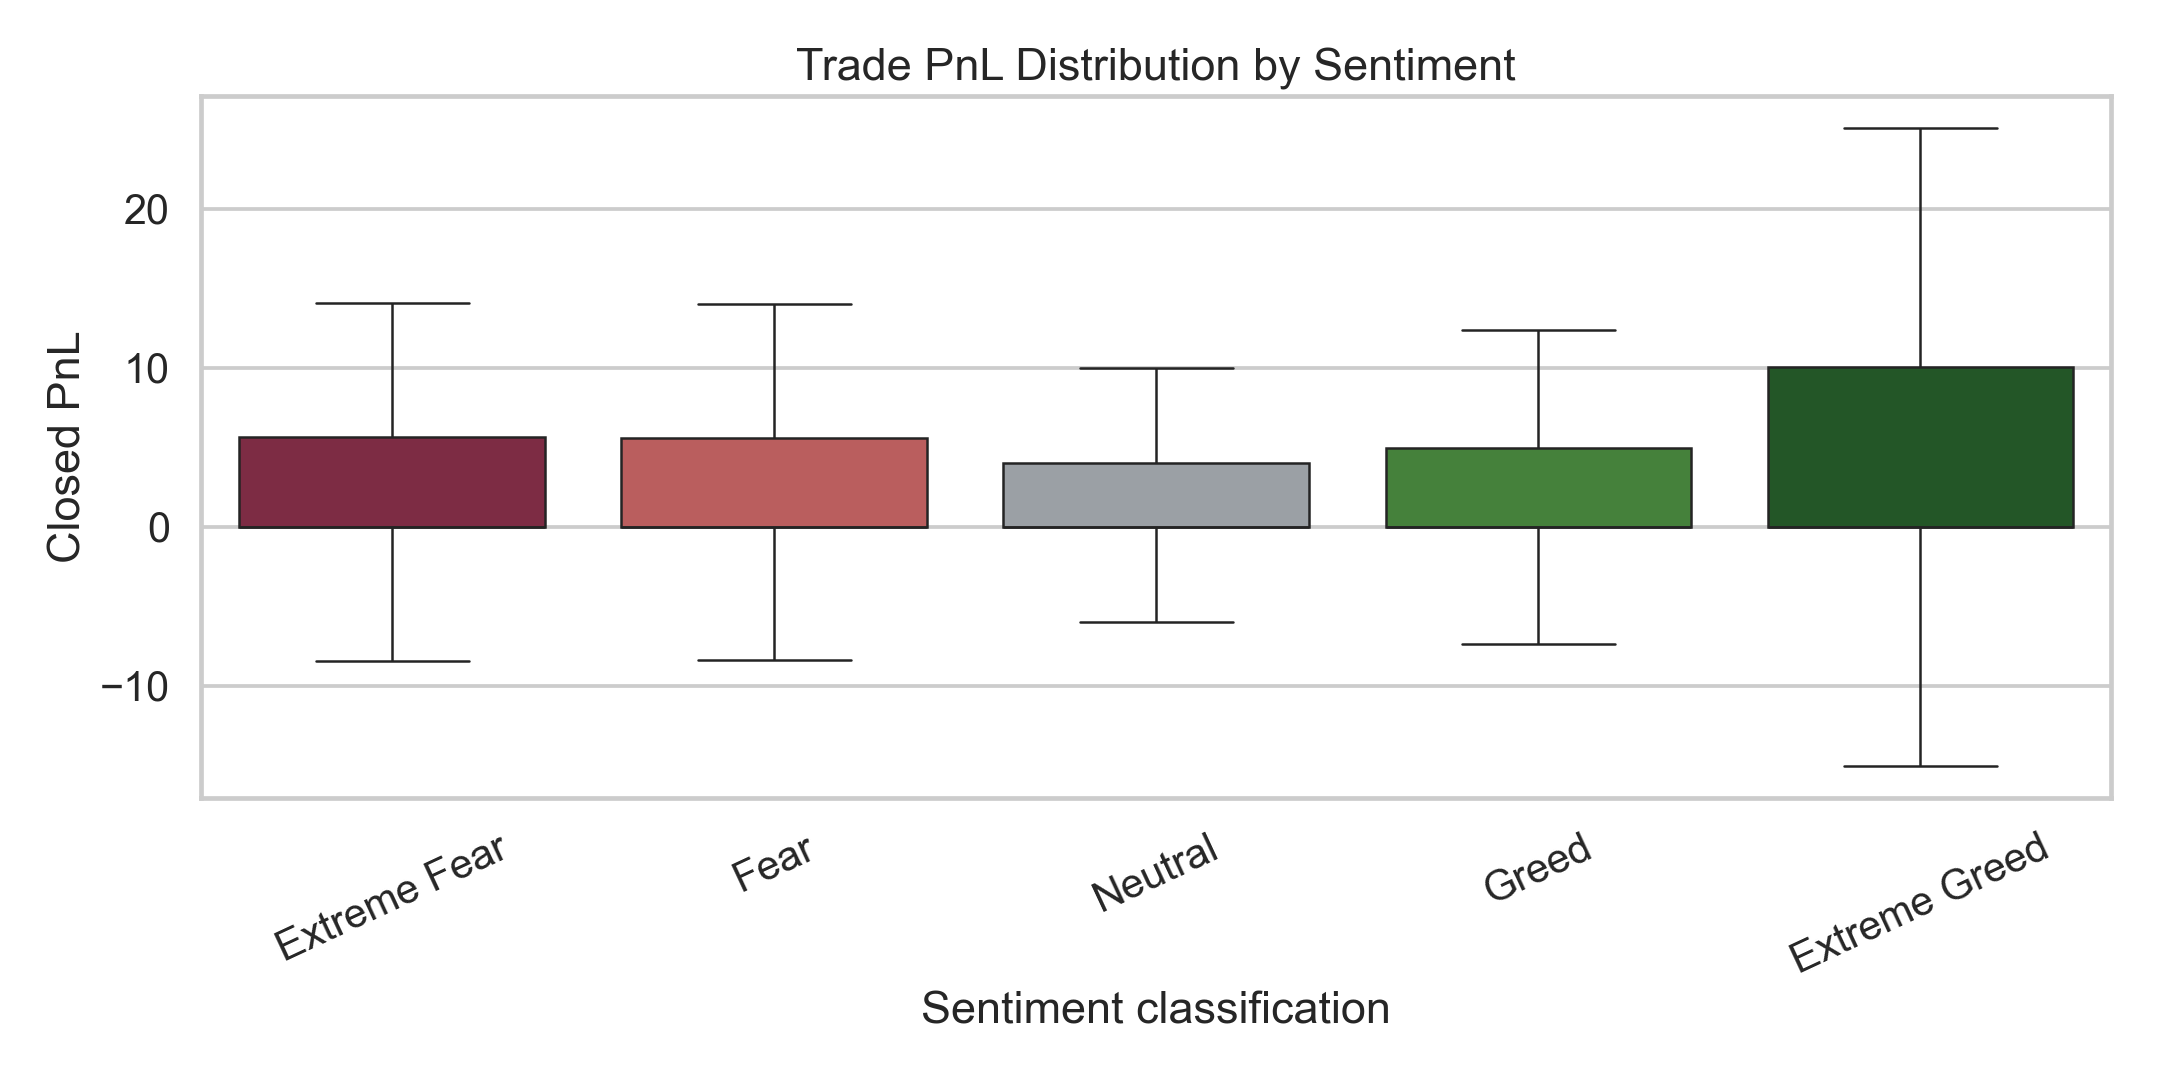

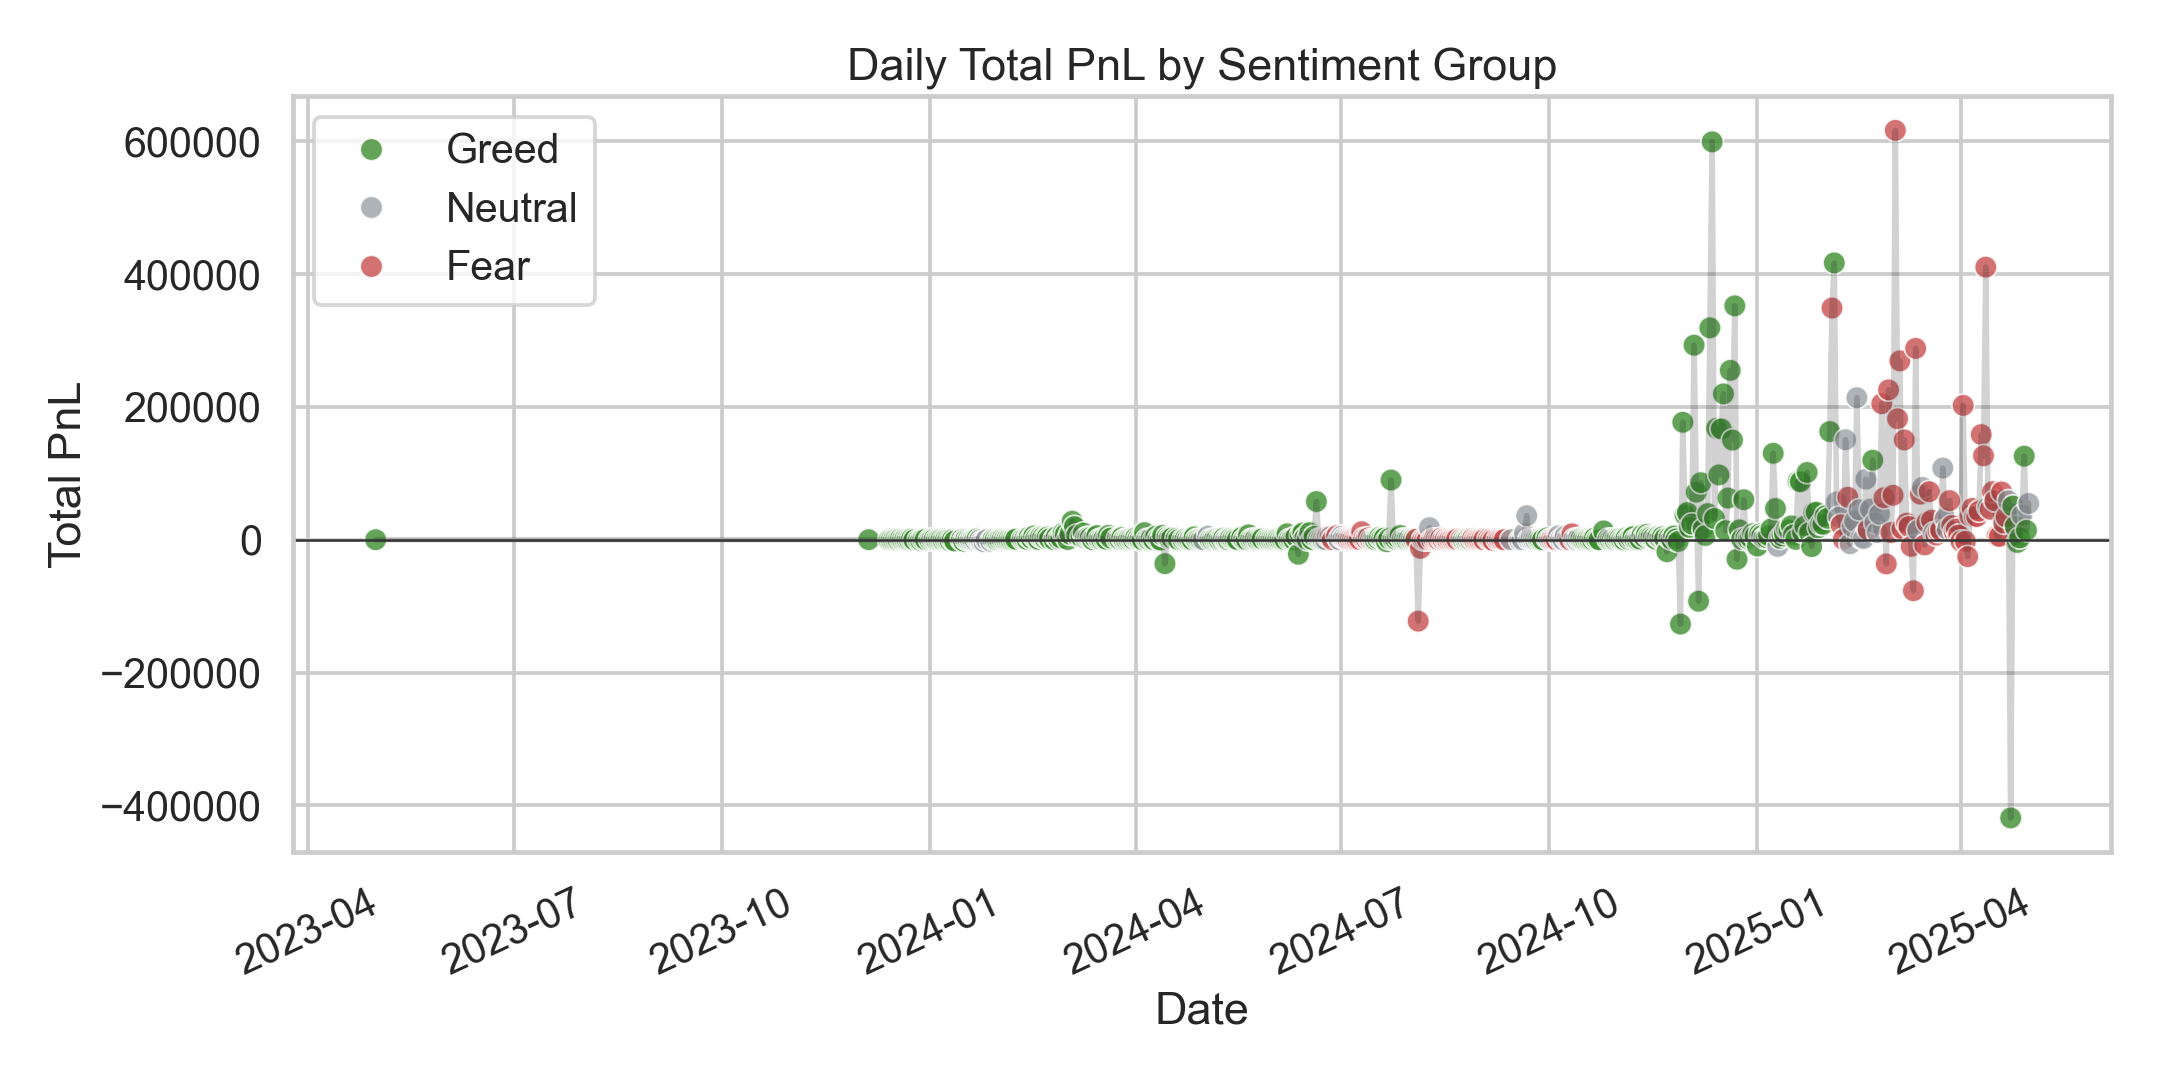

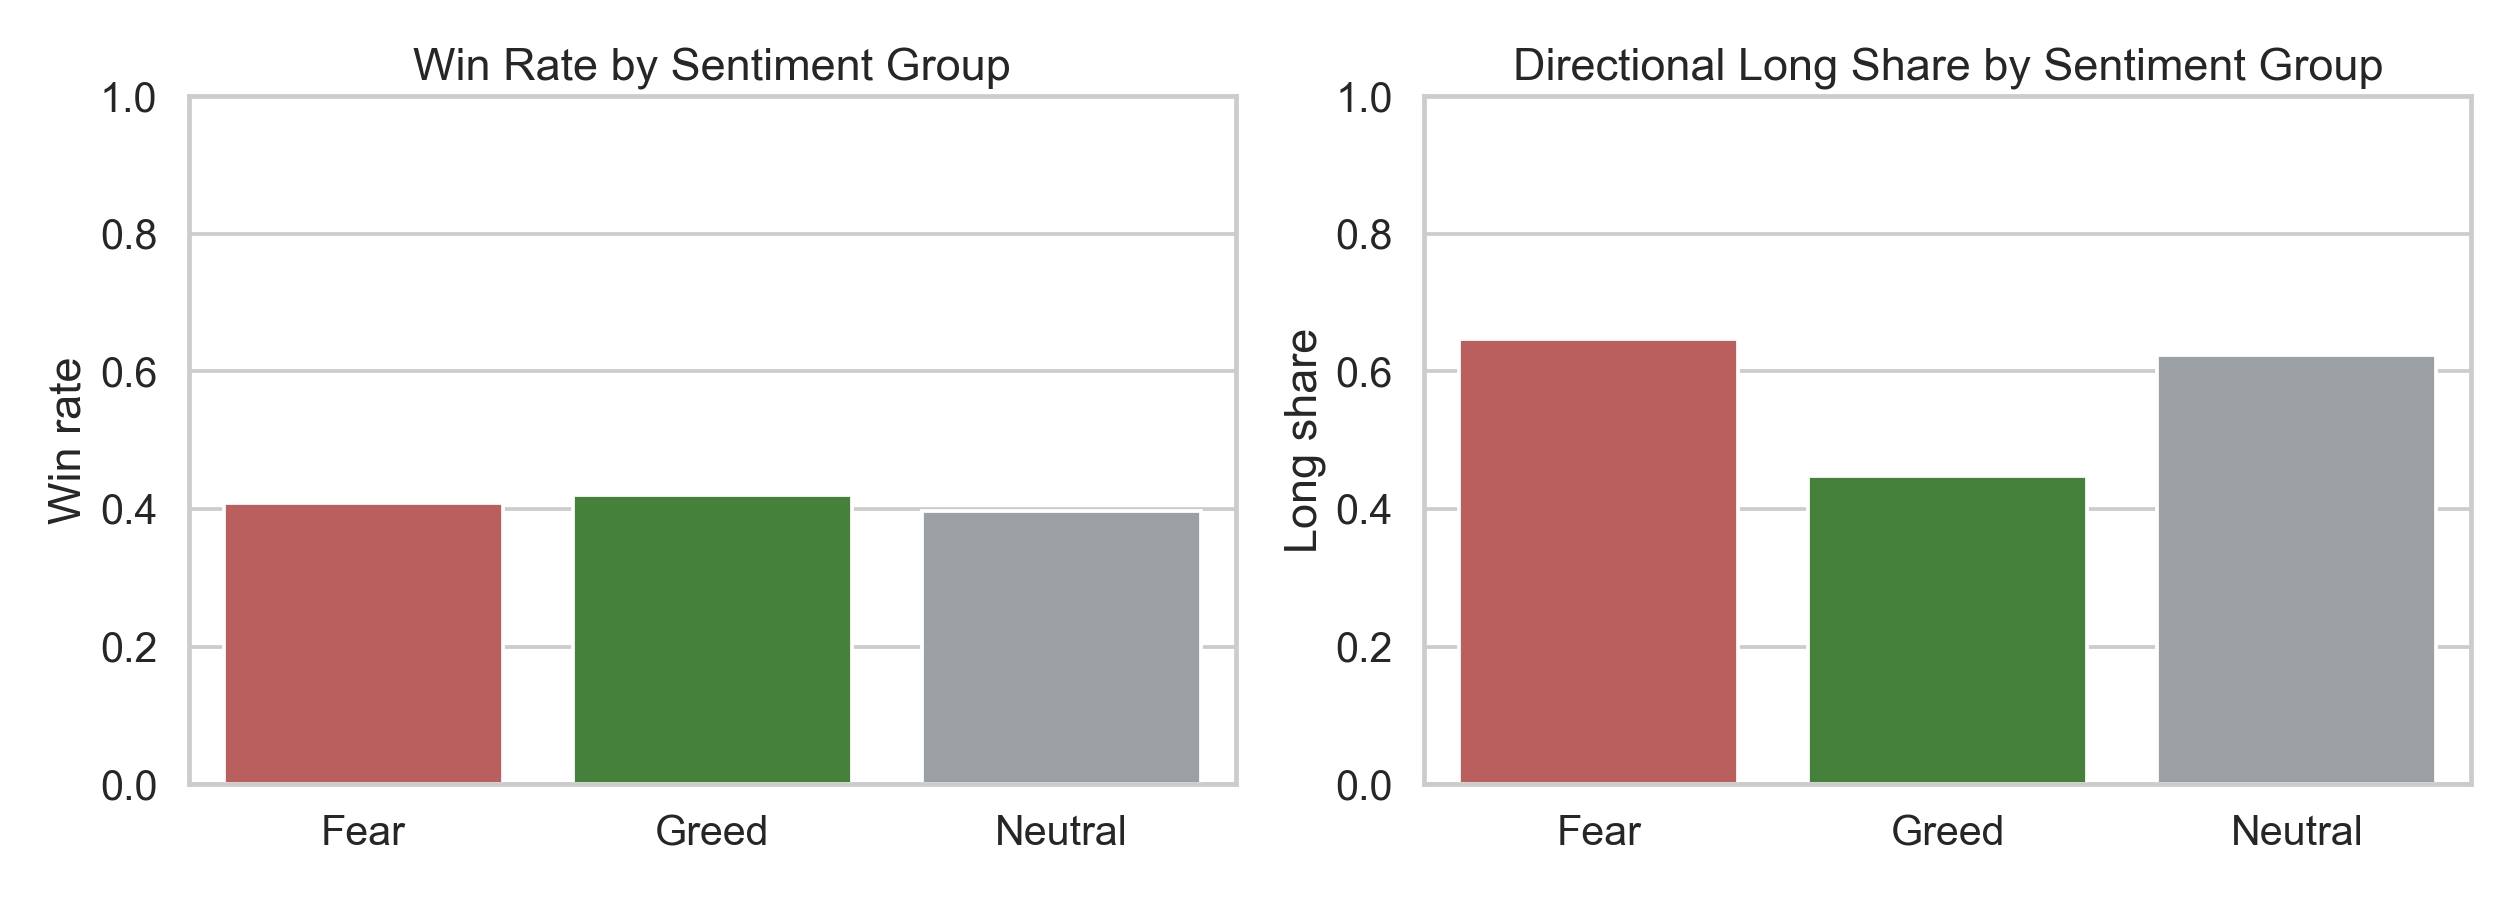

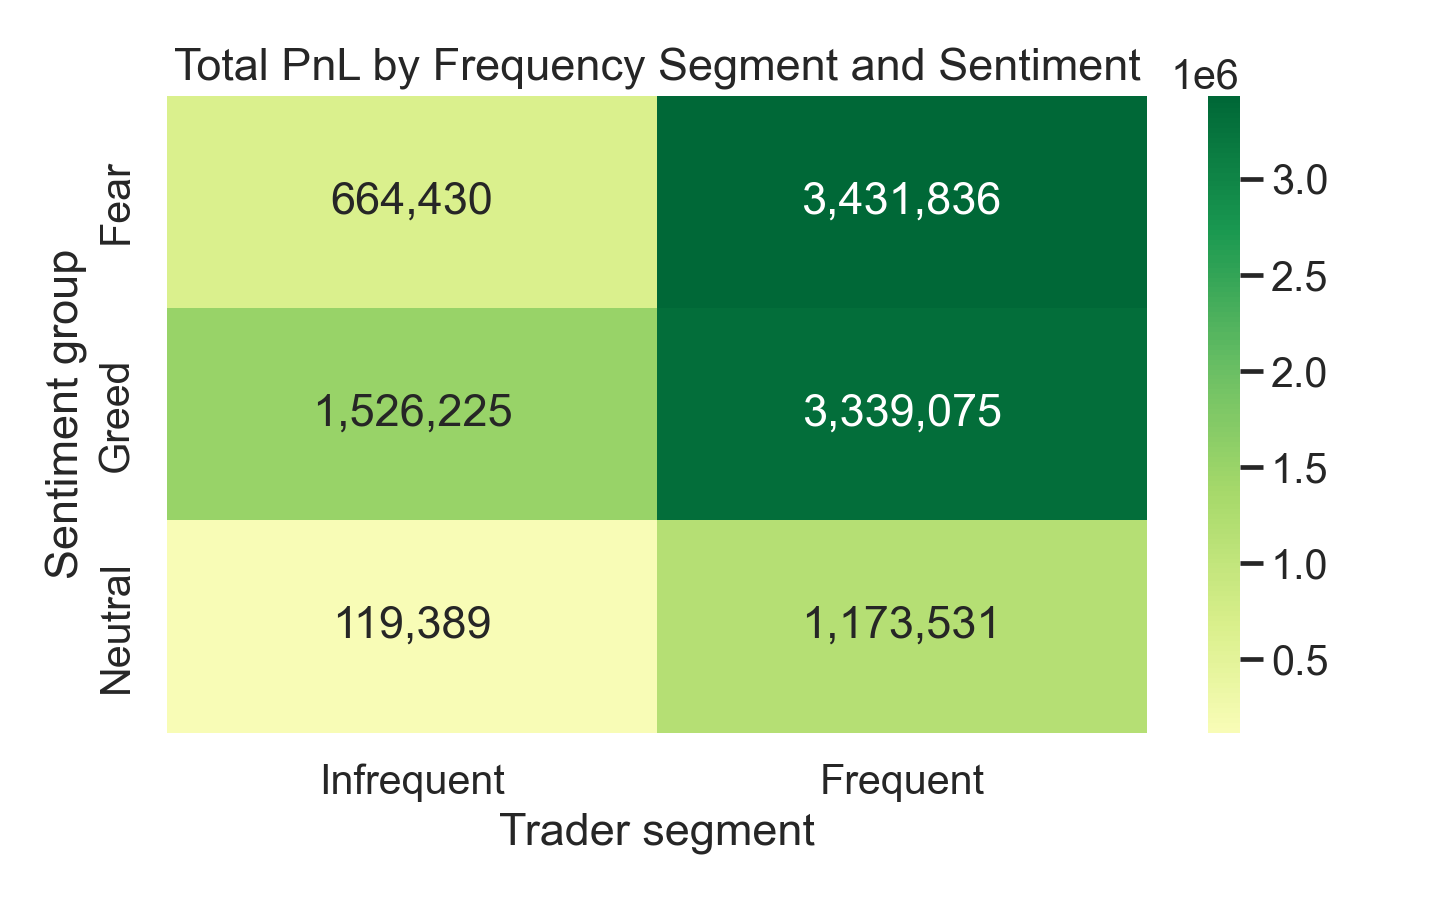

In [9]:
display(Image(filename=str(ROOT / 'outputs' / 'charts' / 'pnl_boxplot_by_sentiment.png')))
display(Image(filename=str(ROOT / 'outputs' / 'charts' / 'daily_total_pnl_by_sentiment.png')))
display(Image(filename=str(ROOT / 'outputs' / 'charts' / 'behavior_by_sentiment.png')))
display(Image(filename=str(ROOT / 'outputs' / 'charts' / 'segment_pnl_heatmap.png')))

## 10. Derive Actionable Strategy Rules

1. During Fear days, keep capital concentrated in frequent traders and reduce size on the highest-ticket cohort unless recent win rate remains strong.
2. During Greed days, cap position size more aggressively and route risk toward consistent accounts rather than inconsistent ones.

## 11. Optional: Predictive Model or Clustering

Bonus model: predict next-day profitability bucket (`loss`, `flat`, `profit`) from sentiment and prior-day activity features.

Model choice: multinomial logistic regression with a time-ordered train/test split (no random shuffle) to reduce leakage.

Target definition:
- `loss`: next-day total PnL < 0
- `flat`: 0 <= next-day total PnL <= median positive PnL
- `profit`: next-day total PnL > median positive PnL

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

bonus_daily = tables['daily_summary'].copy()
bonus_daily = bonus_daily.sort_values('date').reset_index(drop=True)

# Build next-day target from total pnl
bonus_daily['next_day_pnl'] = bonus_daily['total_pnl'].shift(-1)
positive_median = bonus_daily.loc[bonus_daily['next_day_pnl'] > 0, 'next_day_pnl'].median()

bonus_daily['target_bucket'] = np.select(
    [
        bonus_daily['next_day_pnl'] < 0,
        (bonus_daily['next_day_pnl'] >= 0) & (bonus_daily['next_day_pnl'] <= positive_median),
        bonus_daily['next_day_pnl'] > positive_median,
    ],
    ['loss', 'flat', 'profit'],
    default='unknown',
)

model_df = bonus_daily[bonus_daily['target_bucket'] != 'unknown'].copy()

# Features available at end of day t to predict day t+1 bucket
feature_cols_num = ['trades', 'total_pnl', 'mean_pnl', 'win_rate', 'avg_trade_size', 'directional_trades']
feature_cols_cat = ['sentiment_group', 'classification']
X = model_df[feature_cols_num + feature_cols_cat]
y = model_df['target_bucket']

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), feature_cols_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_cat),
    ]
)

clf = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('model', LogisticRegression(max_iter=300, multi_class='auto')),
    ]
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Train rows:', len(X_train), 'Test rows:', len(X_test))
print('\nClass distribution (test):')
print(y_test.value_counts().to_string())
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=['loss', 'flat', 'profit'])
cm_df = pd.DataFrame(cm, index=['actual_loss', 'actual_flat', 'actual_profit'], columns=['pred_loss', 'pred_flat', 'pred_profit'])
display(cm_df)

# Save bonus outputs
cm_df.to_csv(ROOT / 'outputs' / 'tables' / 'bonus_confusion_matrix.csv', index=True)

report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
report_df.to_csv(ROOT / 'outputs' / 'tables' / 'bonus_classification_report.csv', index=True)

print('\nSaved bonus outputs to outputs/tables/.')

Train rows: 382 Test rows: 96

Class distribution (test):
target_bucket
profit    82
loss      10
flat       4

Classification report:
              precision    recall  f1-score   support

        flat      0.000     0.000     0.000         4
        loss      0.000     0.000     0.000        10
      profit      0.850     0.829     0.840        82

    accuracy                          0.708        96
   macro avg      0.283     0.276     0.280        96
weighted avg      0.726     0.708     0.717        96



c:\Users\mahal\Desktop\primetrade-round0\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,pred_loss,pred_flat,pred_profit
actual_loss,0,2,8
actual_flat,0,0,4
actual_profit,2,12,68



Saved bonus outputs to outputs/tables/.
